In [1]:
import numpy as np
import matplotlib.pyplot as plt

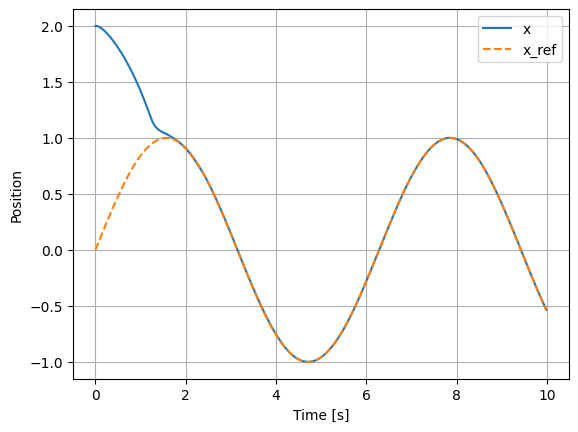

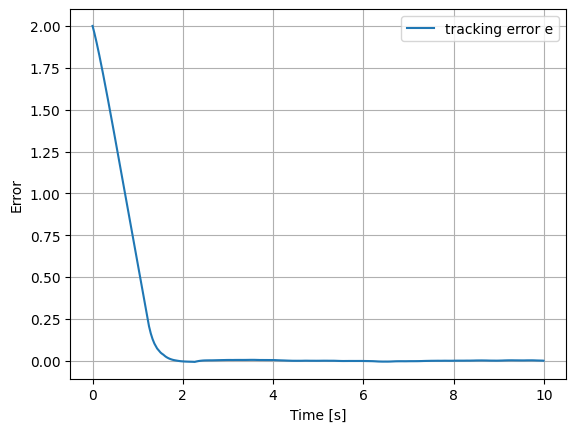

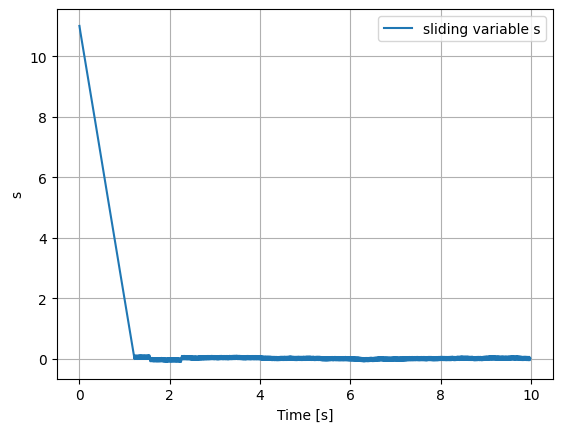

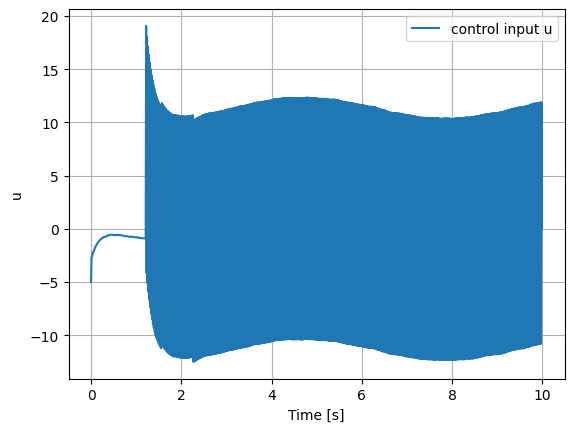

In [2]:
# Settings
dt = 0.01
T = 10.0
t = np.arange(0, T, dt)

# Controller gains
lam = 6.0
k1 = 10.0
k2 = 1.0

# Boundary layer to reduce chattering
eps = 0.02

def sat(x, eps):
    return np.clip(x / eps, -1.0, 1.0)

# Reference trajectory
def x_ref(t):
    return np.sin(t)

def dx_ref(t):
    return np.cos(t)

def ddx_ref(t):
    return -np.sin(t)

# States
x = np.zeros_like(t)
dx = np.zeros_like(t)

# Initial conditions
x[0] = 2.0
dx[0] = 0.0

s_arr = np.zeros_like(t)
u_arr = np.zeros_like(t)

s_prev = 0.0

noise_std = 0.2
noise = np.random.normal(0.0, noise_std, size=t.shape)

# Simulation
for i in range(len(t) - 1):
    # Tracking errors
    e = x[i] - x_ref(t[i])
    de = dx[i] - dx_ref(t[i])

    # Sliding variable
    s = de + lam * e

    # Numerical derivative of s
    ds = (s - s_prev) / dt
    s_prev = s

    # Twisting control part
    #u_twist = -k1 * sat(s, eps) - k2 * sat(ds, eps)
    u_twist = -k1 * np.sign(s) - k2 * np.sign(ds)

    # Equivalent/feedforward part
    u = ddx_ref(t[i]) - lam * de + u_twist

    # Double integrator dynamics
    ddx = u + noise[i]

    dx[i + 1] = dx[i] + ddx * dt
    x[i + 1] = x[i] + dx[i] * dt

    s_arr[i] = s
    u_arr[i] = u

# ---------- Plot ----------
plt.figure()
plt.plot(t, x, label="x")
plt.plot(t, x_ref(t), "--", label="x_ref")
plt.xlabel("Time [s]")
plt.ylabel("Position")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, x - x_ref(t), label="tracking error e")
plt.xlabel("Time [s]")
plt.ylabel("Error")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, s_arr, label="sliding variable s")
plt.xlabel("Time [s]")
plt.ylabel("s")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(t, u_arr, label="control input u")
plt.xlabel("Time [s]")
plt.ylabel("u")
plt.grid(True)
plt.legend()
plt.show()

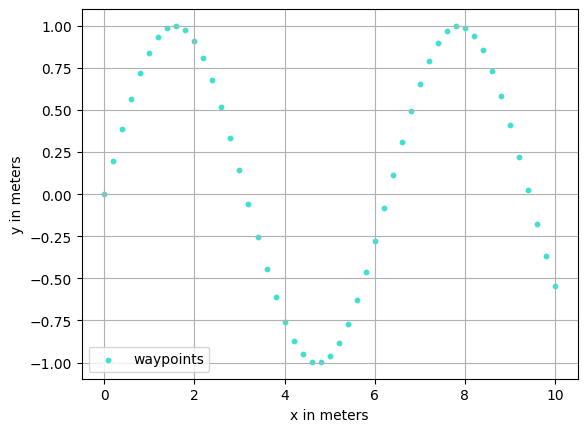

In [3]:
from Models.diffdrive import DiffDrive

robot = DiffDrive()
sim_t = 10.0
zoh_t = 0.2
waypoints = np.zeros((int(sim_t / zoh_t) + 1, 2))
time = 0.0
i = 0
while time < sim_t:
    waypoints[i, 1] = np.sin(time)
    waypoints[i, 0] = time
    i += 1
    time += zoh_t
    
plt.figure()
plt.scatter(waypoints[:, 0], waypoints[:, 1], label="waypoints", color='turquoise', s=10)
plt.xlabel("x in meters")
plt.ylabel("y in meters")
plt.grid(True)
plt.legend()
plt.show()

Time: 0.01 s, State: (np.float64(0.003), np.float64(0.0), np.float64(0.0))
Time: 0.02 s, State: (np.float64(0.005999999999999998), np.float64(0.0), np.float64(0.10999999999999988))
Time: 0.03 s, State: (np.float64(0.008981868293870087), np.float64(0.0003293349025115239), np.float64(0.19999999999999973))
Time: 0.04 s, State: (np.float64(0.01192206802739381), np.float64(0.0009253428948967064), np.float64(0.2899999999999996))
Time: 0.05 s, State: (np.float64(0.014796799653931901), np.float64(0.0017831995702112112), np.float64(0.37999999999999945))
Time: 0.06 s, State: (np.float64(0.01758279356066143), np.float64(0.002895960978450157), np.float64(0.4699999999999993))
Time: 0.07 s, State: (np.float64(0.020257498425247416), np.float64(0.00425461983458736), np.float64(0.5599999999999992))
Time: 0.08 s, State: (np.float64(0.022799263758287662), np.float64(0.005848178428350007), np.float64(0.649999999999999))
Time: 0.09 s, State: (np.float64(0.02518751515393483), np.float64(0.007663737645558123

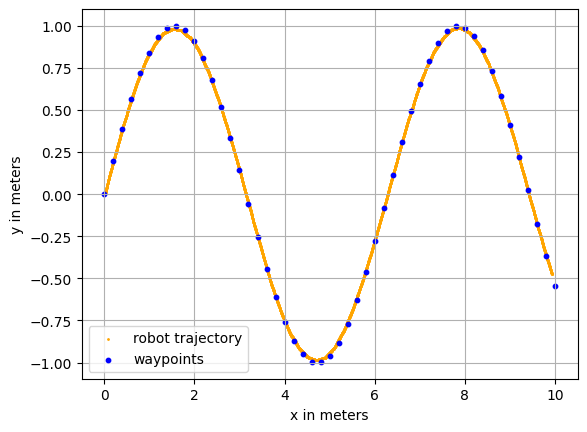

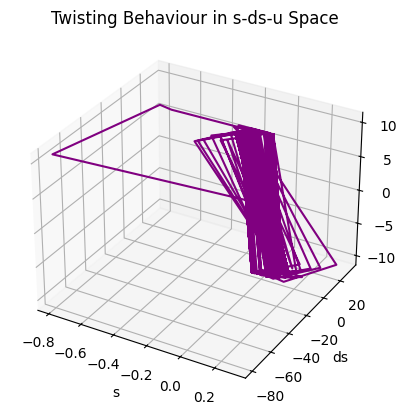

In [11]:
def wrap_to_pi(angle):
    return (angle + np.pi) % (2 * np.pi) - np.pi

class TwistingController:
    def __init__(self, lam=6.0, k1=10.0, k2=1.0, v_cmd=0.3):
        self.lam = lam
        self.k1 = k1
        self.k2 = k2
        self.r = 0.2
        self.L = 0.5
        self.s_prev = 0.0
        self.e_phi_prev = 0.0
        self.omega_cmd = 0.0
        self.v_cmd = v_cmd

    def control(self, x,y, phi, waypoint, dt):
        
        phi_des = np.arctan2(waypoint[1] - y, waypoint[0] - x)
        s = wrap_to_pi(phi - phi_des)
        ds = (s - self.s_prev) / dt
        self.s_prev = s

        omega_cmd = -self.k1 * np.sign(s) - self.k2 * np.sign(ds)

        v_cmd = self.v_cmd

        omega_l = (v_cmd - (self.L / 2) * omega_cmd) / self.r
        omega_r = (v_cmd + (self.L / 2) * omega_cmd) / self.r

        return omega_l, omega_r, omega_cmd, s, ds
    

robot = DiffDrive()
controller = TwistingController()
x = 0.0
y = 0.0
phi = 0.0
sim_t = 5000.0
dt = 0.01
time = 0.0
j = 0
states = []
omega_cmds = []
s_arr = []
ds_arr = []
while j < len(waypoints):
    omega_l, omega_r, omega_cmd, s, ds = controller.control(x, y, phi, waypoints[j], dt)
    new_state = robot.update(omega_l, omega_r, dt)
    x, y, phi = new_state
    states.append(new_state)
    omega_cmds.append(omega_cmd)
    s_arr.append(s)
    ds_arr.append(ds)
    if np.linalg.norm(new_state[:2] - waypoints[j]) < 0.1:
        j += 1
    time += dt
    print(f"Time: {time:.2f} s, State: {new_state}")
states = np.array(states)
s_arr = np.array(s_arr)
ds_arr = np.array(ds_arr)
u = np.array(omega_cmds)

plt.figure()
plt.scatter(states[:, 0], states[:, 1], label="robot trajectory", color='orange', s=1)
plt.scatter(waypoints[:, 0], waypoints[:, 1], label="waypoints", color='blue', s=10)
plt.xlabel("x in meters")
plt.ylabel("y in meters")
plt.grid(True)
plt.legend()
plt.show()

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot(s_arr, ds_arr, u, label="s-ds-u trajectory", color='purple')

ax.set_xlabel("s")
ax.set_ylabel("ds")
ax.set_zlabel("u")
ax.set_title("Twisting Behaviour in s-ds-u Space")

plt.show()